In [1]:
%load_ext autoreload
%autoreload 2

**In case of problems or questions, please first check the list of [Frequently Asked Questions (FAQ)](https://stardist.net/docs/faq.html).**

Please shutdown all other training/prediction notebooks before running this notebook (as those might occupy the GPU memory otherwise).

In [2]:
from __future__ import print_function, unicode_literals, absolute_import, division
import sys
import numpy as np
import matplotlib
matplotlib.rcParams["image.interpolation"] = 'none'
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import PIL
from PIL import Image

from glob import glob
from tqdm import tqdm
from skimage import io
from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score
from skimage.transform import resize
from csbdeep.utils import Path, normalize_mi_ma

In [3]:
from stardist import fill_label_holes, random_label_cmap, calculate_extents, gputools_available
from stardist.matching import matching, matching_dataset
from stardist.models import Config2D, StarDist2D, StarDistData2D

np.random.seed(42)
lbl_cmap = random_label_cmap()

2025-05-30 17:00:46.035719: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-30 17:00:47.502707: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-30 17:00:47.512495: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-30 17:00:49.166462: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-30 17:01:11.803395: W tensorflow/com

# Data

We assume that data has already been downloaded in via notebook [1_data.ipynb](1_data.ipynb).  
We now load images from the sub-folder `test` that have not been used during training.

In [4]:
slide_id = "240819_Ji_N1_H_EScan"
X = sorted(glob(f'/hpc/group/yizhanglab/zs144/Zion-ZhangLab/projects/segment_neurons/output/{slide_id}/patches_2048/*.png'))
Y = sorted(glob(f'/hpc/group/yizhanglab/zs144/Zion-ZhangLab/projects/segment_neurons/output/{slide_id}/pseudo_gt_masks_2048/*.png'))
assert all(Path(x).name==Path(y).name for x,y in zip(X,Y))

X = [io.imread(x) for x in X]
Y = [io.imread(y) for y in Y]
Y = [(mask // 255).astype(np.uint8) for mask in Y]
n_channel = 1 if X[0].ndim == 2 else X[0].shape[-1]

axis_norm = (0,1) # normalize channels independently
# axis_norm = (0,1,2) # normalize channels jointly
if n_channel > 1:
    print("Normalizing image channels %s." % ('jointly' if axis_norm is None or 2 in axis_norm else 'independently'))
    sys.stdout.flush()

X = [normalize_mi_ma(x, 0, 255) for x in tqdm(X)]
Y = [fill_label_holes(y) for y in tqdm(Y)]
# resize image
target_size = (256, 256)
X = [resize(x, target_size, anti_aliasing=False).astype(np.float32) for x in tqdm(X)]
Y = [(resize(y, target_size, anti_aliasing=False) > 0).astype(np.uint8) for y in tqdm(Y)]

assert len(X) > 1, "not enough training data"
X_trn, X_test, Y_trn, Y_test = train_test_split(X, Y, test_size=0.15, random_state=42)
print('number of images: %3d' % len(X))
print('- training:       %3d' % len(X_trn))
print('- validation:     %3d' % len(X_test))

Normalizing image channels independently.


100%|██████████| 106/106 [00:01<00:00, 88.07it/s]

number of images: 106
- training:        90
- validation:      16


In [5]:
# # show all test images
# if False:
#     fig, ax = plt.subplots(7,8, figsize=(16,16))
#     for i,(a,x) in enumerate(zip(ax.flat, X)):
#         a.imshow(x if x.ndim==2 else x[...,0], cmap='gray')
#         a.set_title(i)
#     [a.axis('off') for a in ax.flat]
#     plt.tight_layout()
# None;

# Load trained model

If you trained your own StarDist model (and optimized its thresholds) via notebook [2_training.ipynb](2_training.ipynb), then please set `demo_model = False` below.

In [6]:
model_ckpt_path_1 = "/hpc/group/yizhanglab/zs144/repo/Zion-stardist/examples/2D/models/models_v0.9"
# model_ckpt_path_1 = "/hpc/group/yizhanglab/zs144/repo/Zion-stardist/zion_assets/models/test_run_v0.1"
model_1 = StarDist2D(None, name='stardist', basedir=model_ckpt_path_1)

2025-05-30 17:02:35.432521: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-05-30 17:02:35.795775: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.793201, nms_thresh=0.3.


## Prediction

Make sure to normalize the input image beforehand or supply a `normalizer` to the prediction function.

Calling `model.predict_instances` will
- predict object probabilities and star-convex polygon distances (see `model.predict` if you want those)
- perform non-maximum suppression (with overlap threshold `nms_thresh`) for polygons above object probability threshold `prob_thresh`.
- render all remaining polygon instances in a label image
- return the label instances image and also the details (coordinates, etc.) of all remaining polygons

In [7]:
img = X_test[0]
labels, details = model_1.predict_instances(img, prob_thresh=0.1)

functional.py (237): The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(1, 256, 256, 3))


In [8]:
labels.shape # shape of the input image
np.unique(labels)

array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=int32)

In [9]:
type(labels)

numpy.ndarray

In [10]:
# shape: n_instances * 2 * n_rays
# The details contain the polygon boundary of these detected objects. Each
# has `n_rays` 2D points.
details
# details["coord"].shape

{'coord': array([[[104.      , 107.86788 , 111.82157 , 116.22786 , 120.167534,
          123.626396, 126.95081 , 127.9517  , 129.1001  , 128.38202 ,
          127.686134, 125.52592 , 122.64336 , 118.172264, 113.30002 ,
          108.58367 , 104.      ,  99.61815 ,  95.108536,  91.18916 ,
           87.403076,  85.10225 ,  83.743866,  83.459015,  82.48369 ,
           83.568436,  83.693855,  85.67851 ,  88.48871 ,  91.895645,
           96.05569 , 100.16079 ],
         [123.48215 , 123.44516 , 122.88294 , 122.300285, 120.167534,
          117.11394 , 113.50654 , 108.76429 , 104.      ,  99.150116,
           94.18888 ,  89.61684 ,  85.35664 ,  82.7897  ,  81.547775,
           80.95632 ,  81.09261 ,  81.97093 ,  82.53412 ,  84.827225,
           87.403076,  91.37293 ,  95.609634,  99.91415 , 104.      ,
          108.06409 , 112.41108 , 116.24203 , 119.51129 , 122.11545 ,
          123.17927 , 123.30101 ]],
 
        [[ 44.      ,  48.005917,  52.231724,  56.591564,  60.24815 ,
        

(-0.5, 255.5, 255.5, -0.5)

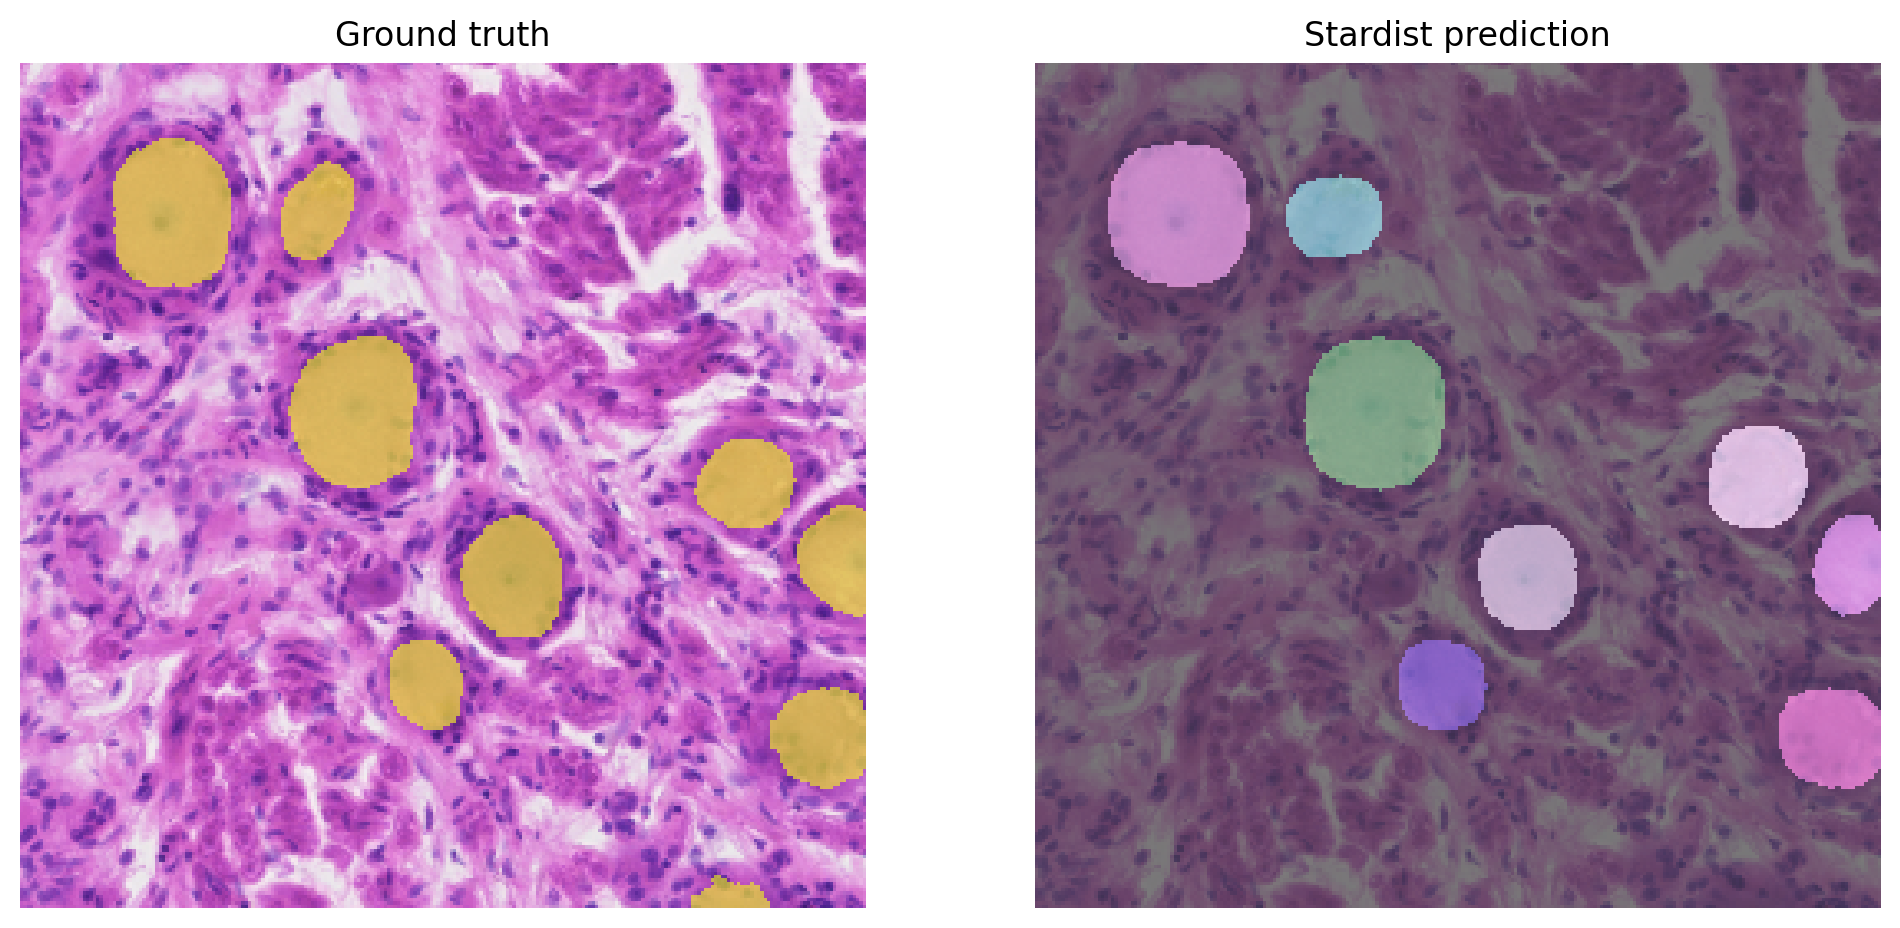

In [13]:
image = X_test[0]
gt_mask = Y_test[0]

fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].imshow(image)
color = np.array([251 / 255, 252 / 255, 30 / 255, 0.6])
h, w = gt_mask.shape[-2:]
show_gt_mask = gt_mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
axes[0].imshow(show_gt_mask)
axes[0].axis('off')
axes[0].set_title("Ground truth");

axes[1].imshow(image, alpha=0.7)
axes[1].imshow(labels, cmap=lbl_cmap, alpha=0.5)
axes[1].set_title("Stardist prediction")
axes[1].axis('off')

In [7]:
# from PIL import Image 

# # save a image using extension
# image = X_test[0]
# im = Image.fromarray((image* 255).astype(np.uint8))
# im = im.save("/hpc/group/yizhanglab/zs144/Zion-ZhangLab/projects/segment_neurons/temp/example.jpg")

In [9]:
Y_test_pred = [(model_1.predict_instances(x, prob_thresh=0.2)[0] > 0).astype(np.uint8)
               for x in tqdm(X_test[0:10])]

100%|██████████| 10/10 [00:01<00:00,  8.50it/s]


In [10]:
def plot_binary_mask_comparison(ax, pred_mask: np.ndarray, true_mask: np.ndarray,
                                has_legend=True) -> None:
    """Plot the predicted mask and ground truth mask over the image, with the true
    positive area colored as green, the true negatives as red, and the false negatives
    as yellow. The orginal image is shown in the background."""
    TP = np.logical_and(pred_mask, true_mask)
    FP = np.logical_and(pred_mask, np.logical_not(true_mask))
    FN = np.logical_and(np.logical_not(pred_mask), true_mask)

    mask_comparison = np.zeros((pred_mask.shape[0], pred_mask.shape[1], 3))
    mask_comparison[TP.squeeze(), :] =  [0, 1, 0] # green
    mask_comparison[FP.squeeze(), :] =  [1, 0, 0] # red
    mask_comparison[FN.squeeze(), :] =  [0.5, 0.5, 0.5] # gray

    # create legend and add it to the right of the image (outside)
    green_patch = mpatches.Patch(color='green', label='TP')
    red_patch   = mpatches.Patch(color='red', label='FP')
    yellow_patch = mpatches.Patch(color='gray', label='FN')
    if has_legend:
        ax.legend(handles=[green_patch, red_patch, yellow_patch],
                  loc='center left', bbox_to_anchor=(1, 0.5))

    ax.imshow(mask_comparison)

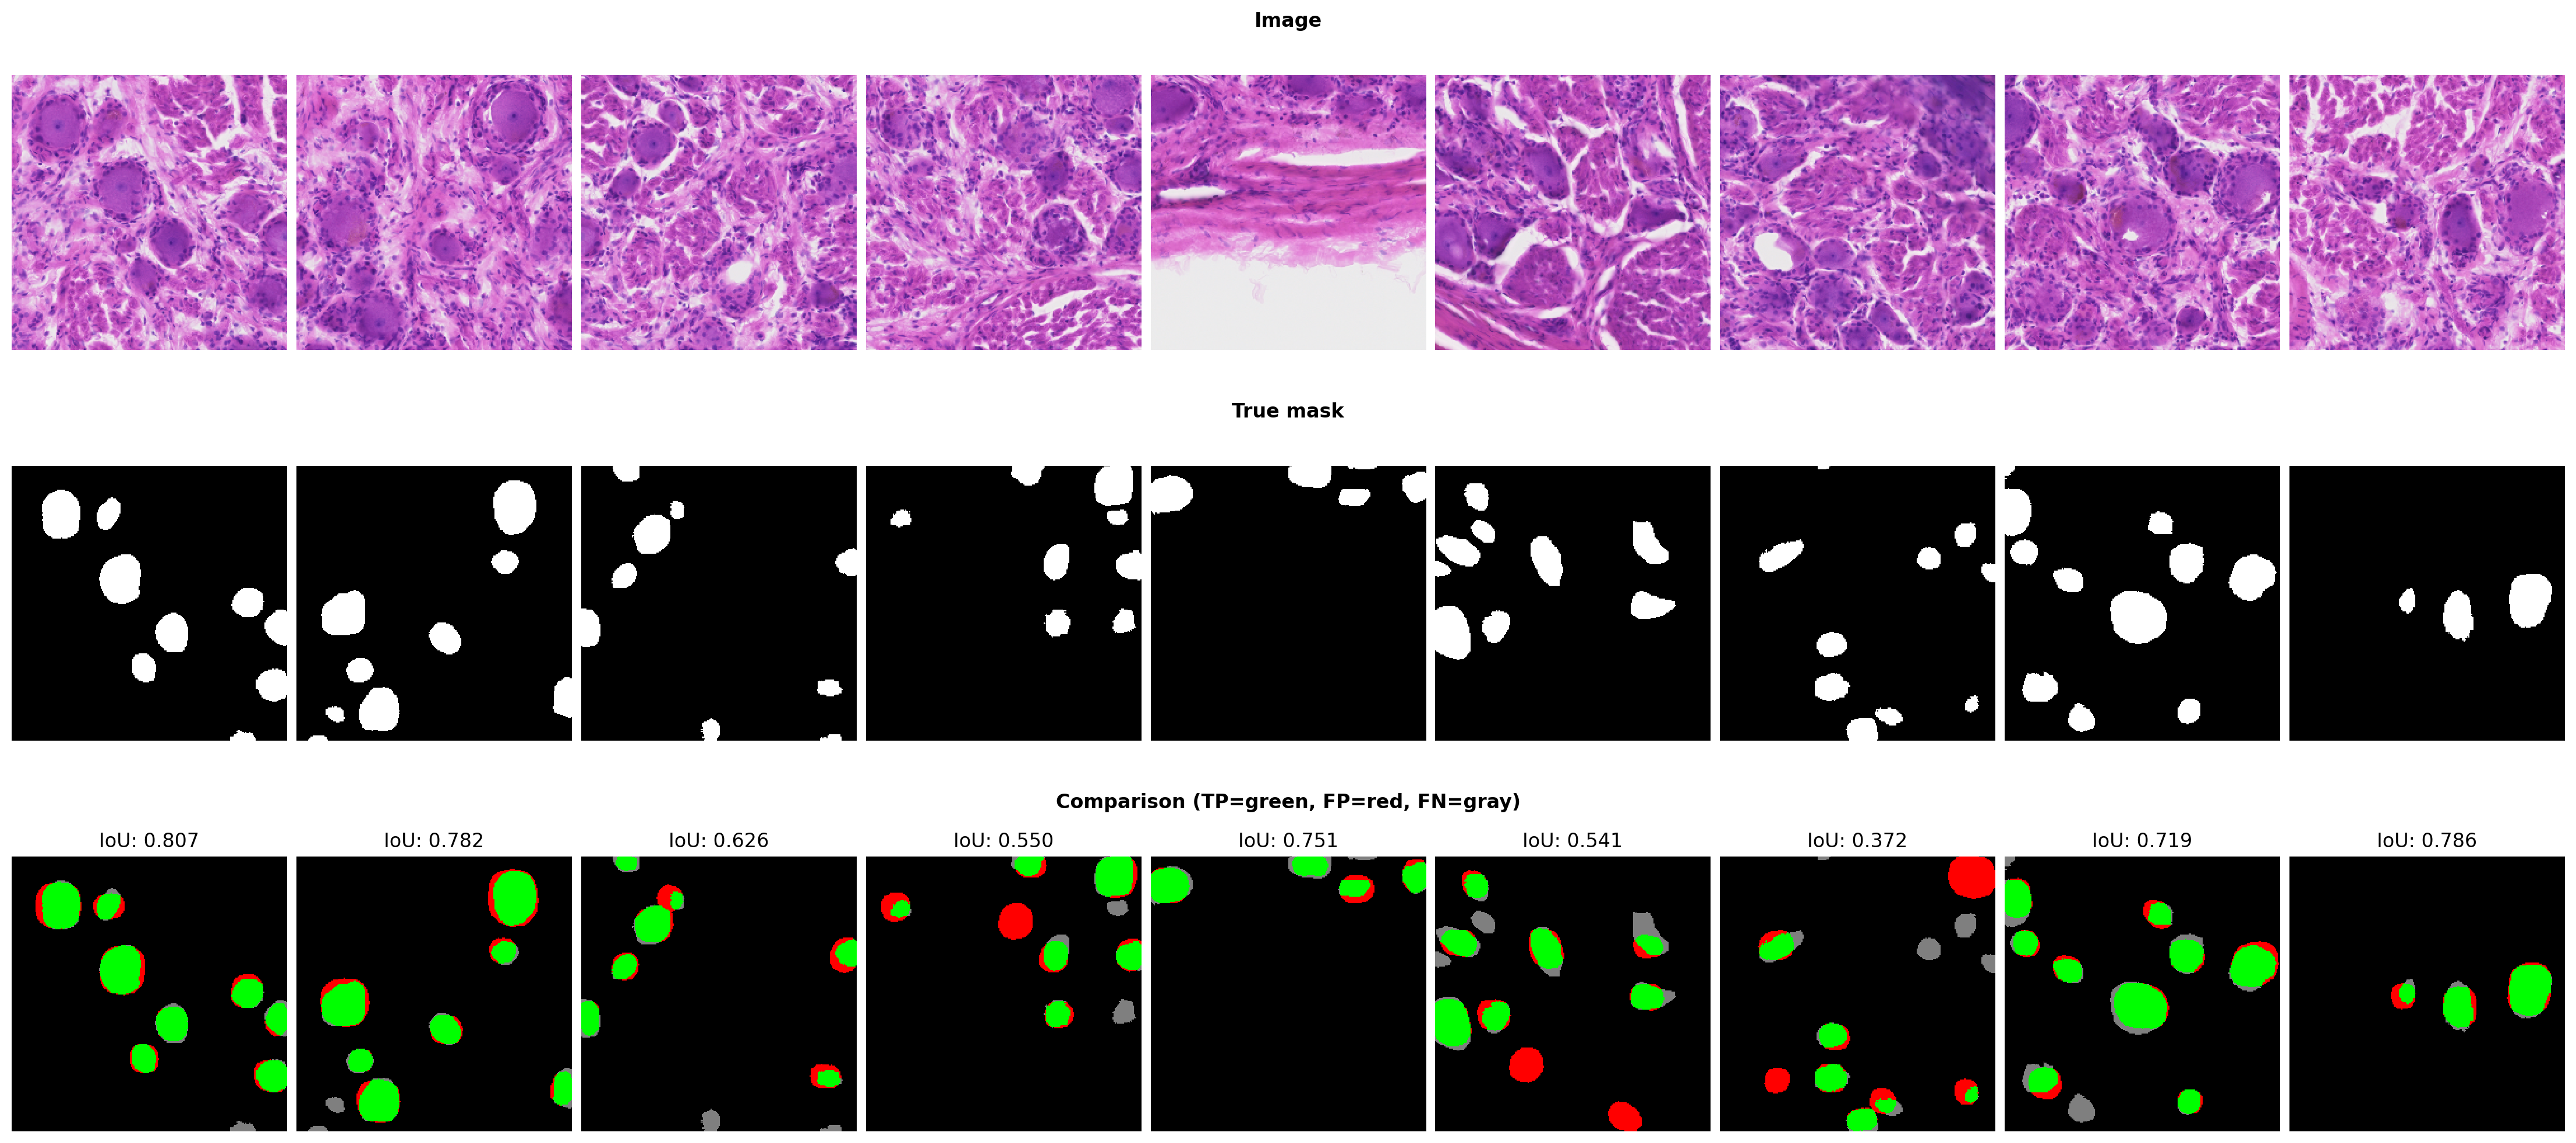

In [11]:
from PIL import Image

fig = plt.figure(figsize=(22, 10), constrained_layout=True)
subfigs = fig.subfigures(nrows=3, ncols=1)
subfigs[0].suptitle('Image', fontweight='bold')
subfigs[1].suptitle('True mask', fontweight='bold')
subfigs[2].suptitle('Comparison (TP=green, FP=red, FN=gray)', fontweight='bold')
ax0 = subfigs[0].subplots(nrows=1, ncols=9)
ax1 = subfigs[1].subplots(nrows=1, ncols=9)
ax2 = subfigs[2].subplots(nrows=1, ncols=9)

for i in range(9):
    image     = X_test[i]
    true_mask = Y_test[i]
    pred_mask = Y_test_pred[i]
    ax0[i].imshow(image)
    ax0[i].axis('off')
    ax1[i].imshow(true_mask, cmap='gray')
    ax1[i].axis('off')
    iou = jaccard_score(true_mask.flatten(), pred_mask.flatten(), average='binary')
    # iou = IoU(device=pred_mask.device, num_classes=NUM_CLASSES)(pred_mask, true_mask)
    ax2[i].set_title(f"IoU: {iou:.3f}")
    plot_binary_mask_comparison(ax2[i], pred_mask, true_mask, has_legend=False)
    ax2[i].axis('off')

In [ ]:
model_ckpt_path_2 = "/hpc/group/yizhanglab/zs144/repo/Zion-stardist/zion_assets/models/test_run_v1.0"
model_2 = StarDist2D(None, name='stardist', basedir=model_ckpt_path_2)

In [13]:
Y_test_pred = [(model_2.predict_instances(x, prob_thresh=0.2)[0] > 0).astype(np.uint8)
               for x in tqdm(X_test[0:10])]

  0%|          | 0/10 [00:00<?, ?it/s]functional.py (237): The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(1, 256, 256, 3))
100%|██████████| 10/10 [00:01<00:00,  8.24it/s]


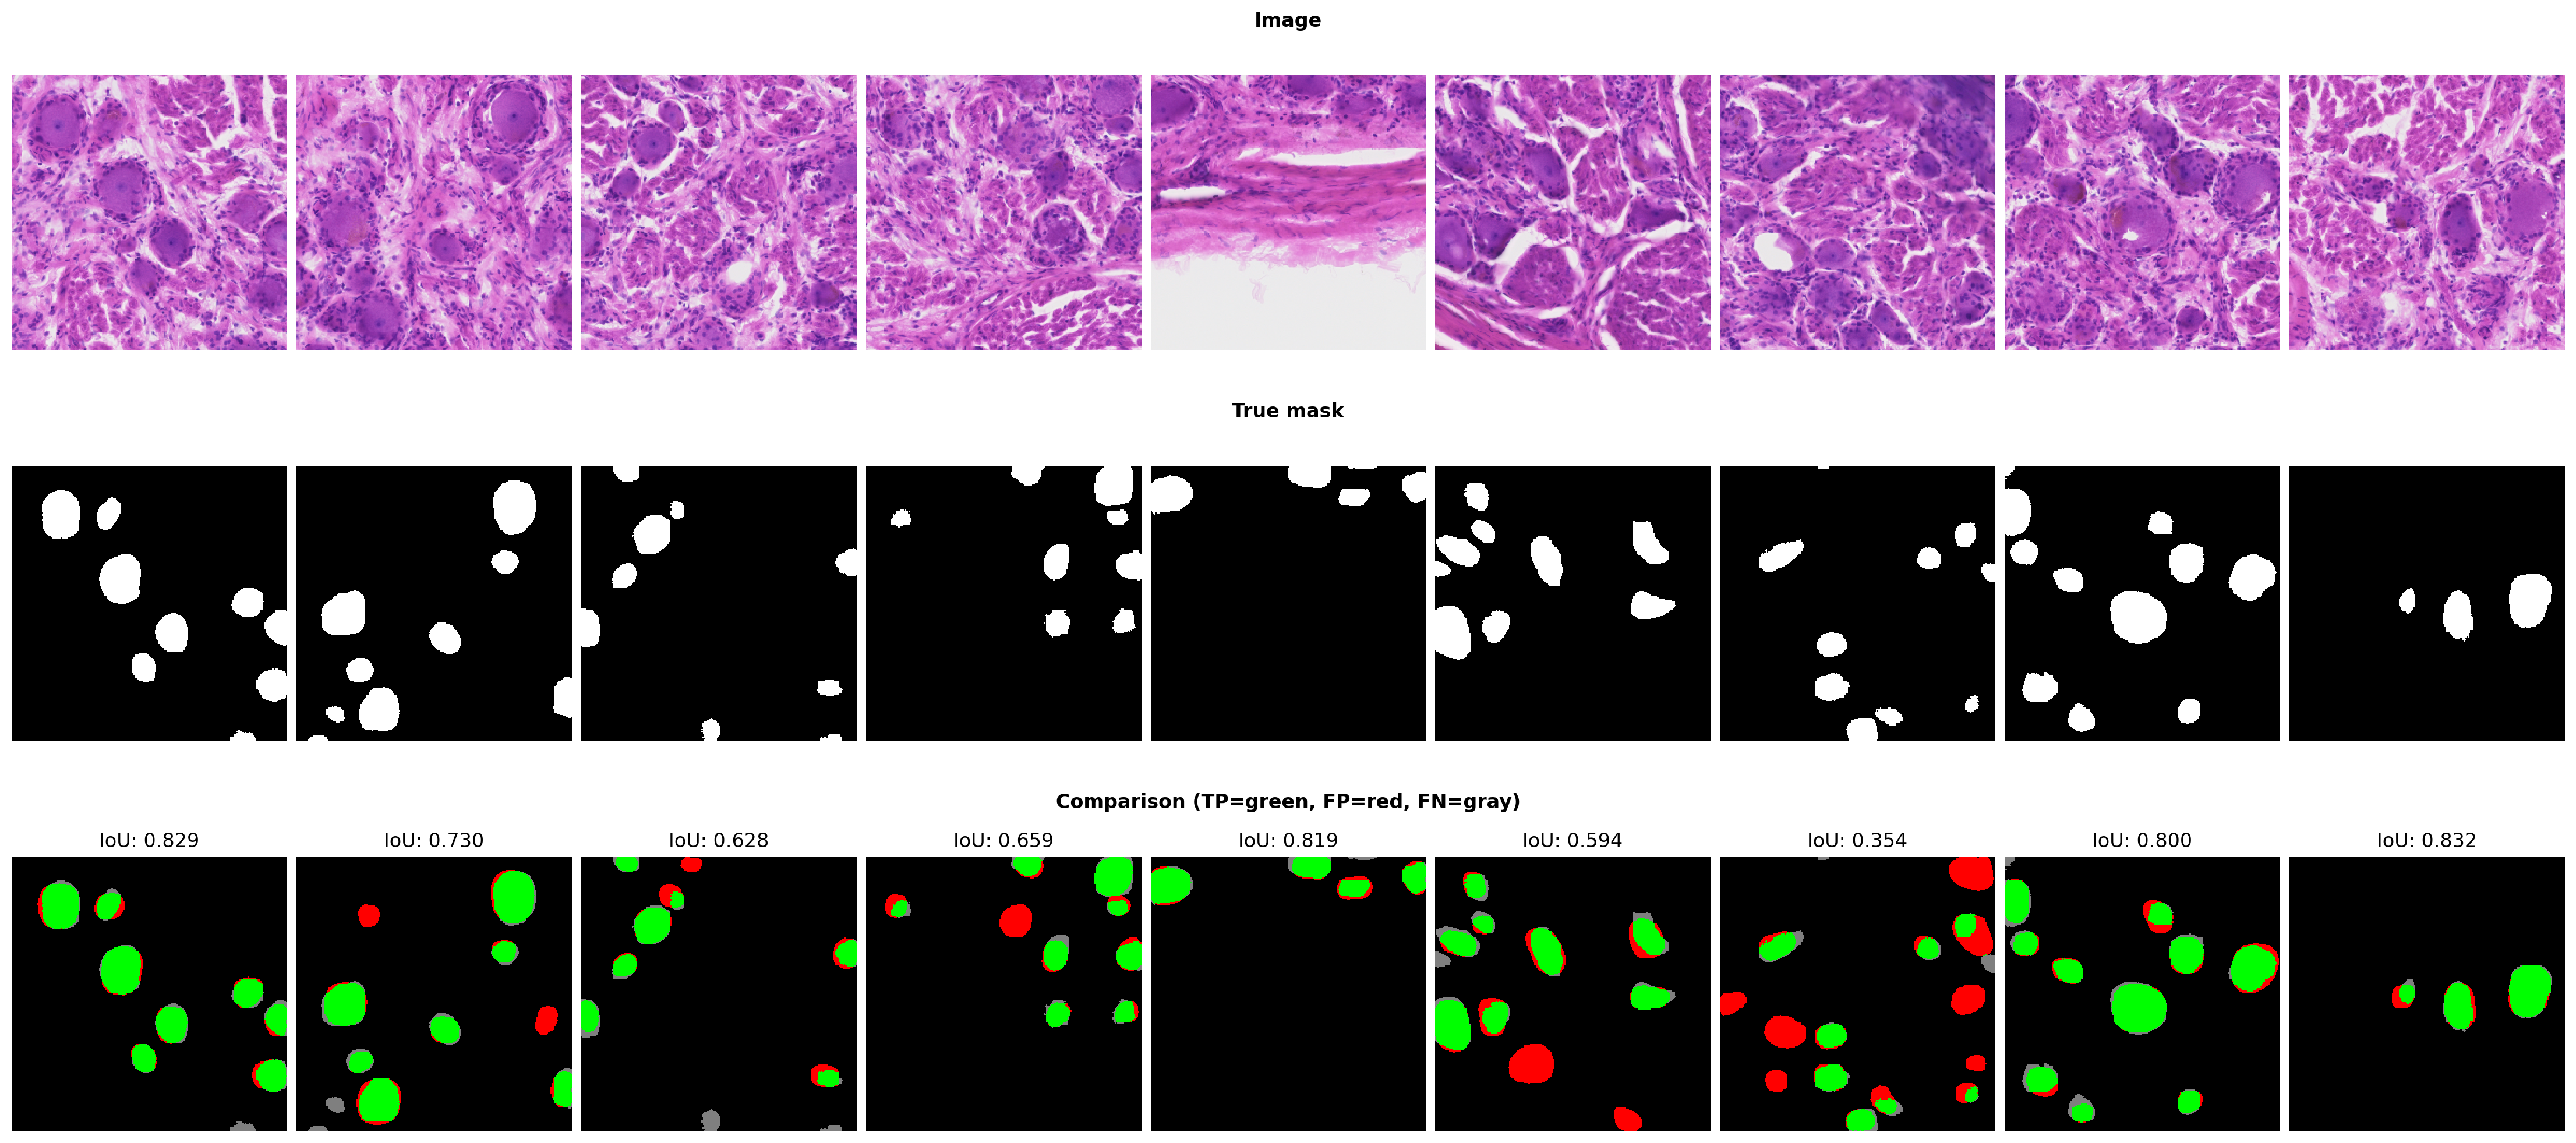

In [14]:
from PIL import Image

fig = plt.figure(figsize=(22, 10), constrained_layout=True)
subfigs = fig.subfigures(nrows=3, ncols=1)
subfigs[0].suptitle('Image', fontweight='bold')
subfigs[1].suptitle('True mask', fontweight='bold')
subfigs[2].suptitle('Comparison (TP=green, FP=red, FN=gray)', fontweight='bold')
ax0 = subfigs[0].subplots(nrows=1, ncols=9)
ax1 = subfigs[1].subplots(nrows=1, ncols=9)
ax2 = subfigs[2].subplots(nrows=1, ncols=9)

for i in range(9):
    image     = X_test[i]
    true_mask = Y_test[i]
    pred_mask = Y_test_pred[i]
    ax0[i].imshow(image)
    ax0[i].axis('off')
    ax1[i].imshow(true_mask, cmap='gray')
    ax1[i].axis('off')
    iou = jaccard_score(true_mask.flatten(), pred_mask.flatten(), average='binary')
    # iou = IoU(device=pred_mask.device, num_classes=NUM_CLASSES)(pred_mask, true_mask)
    ax2[i].set_title(f"IoU: {iou:.3f}")
    plot_binary_mask_comparison(ax2[i], pred_mask, true_mask, has_legend=False)
    ax2[i].axis('off')